In [19]:
#impots
import os
import scipy.sparse as sp
from scipy.sparse import coo_matrix
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.linalg import eig
from sympy import composite

## **Generating graph and then calculating the epi threshold**


generate graph statistcs based on gravity theory

In [391]:
def radiation_model(number_nodes, positions, population):

    rows,cols, weights = [], [], []

    for i in range(number_nodes):
        distance = np.sqrt(((positions[i] - positions) ** 2).sum(axis=1))
        distance[i] = np.inf
        distance[distance == 0] = 0.1


        #radiation model simini paper
        #flow ij = mi * ( minj/ (mi + sij) * (mi + nj + sij))
        #sij = sum of populations in distance between city i and j minus original

        #change self flow


        all_flows = []
        for j in range(number_nodes):
            if j == i:
                 flow = np.random.uniform(0.25, 0.40) * population[i] #selfflows
            else:
                r_ij = distance[j]
                # print(r_ij)
                # if r_ij > 5000: # distance cutoff
                #     flow = 0
                #     continue
                # else:
                s_ij = population[(distance < r_ij)].sum() - population[i] - population[j]
                s_ij = max(0,  s_ij) #no negative s

                first_term = population[i] * population[j]
                second_term = (population[i] + s_ij) * (population[i] + population[j] + s_ij)
                if second_term > 0:
                    log_flow = np.log(population[i]) + np.log(first_term) - np.log(second_term)
                    flow = np.exp(log_flow)

            all_flows.append(flow)



       #urban scaling theory geoffery west luisbettern court
        # target_k = number_nodes * 0.08
        # k = int(target_k * (population [i]  / np.mean(population))**0.5) #scale based on popualtion
        # k= np.clip(k, 1, 500)
        # top_idx = np.argpartition(all_flows, -k)[-k:]
        # #print(k)


        k = np.random.uniform(0.015, 0.085)
        k= int(k * number_nodes)
        top_idx = np.argpartition(all_flows, -k)[-k:]

        for j in top_idx:
            rows.append(i)
            cols.append(j)
            weights.append(all_flows[j])

        #print(flow)

    row_sums = np.bincount(rows, weights=weights, minlength=number_nodes)
    row_sums[row_sums == 0] = 1
    weights = weights / row_sums[rows]

    #print(weights)

    return np.array(rows), np.array(cols), np.array(weights)





In [21]:
def gravity_hubs(number_nodes, positions, population, gamma = 0.4):
    rows,cols, weights = [], [], []

    hubs_idx = np.argsort(population)[- int(number_nodes * 0.05):] #top 5%

    for i in hubs_idx:
        hub_positions = positions[hubs_idx]
        hub_population = population[hubs_idx]

        distances = np.sqrt(((hub_positions[i] - hub_positions) ** 2).sum(axis=1))
        distances[i] = np.inf
        distances[distances == 0] = 0.1

        #attraction = g * (m * m) / d^gamma
        flow = (hub_population[i] * hub_population) / (distances ** gamma)
        flow[i] = 0
        flow = np.asarray(flow).flatten()

        for local_idx, f in enumerate(flow):
            global_j = hubs_idx[local_idx]
            if global_j != i and f > 0:
                rows.append(i)
                cols.append(global_j)
                weights.append(f)

    row_sums = np.bincount(rows, weights=weights, minlength=number_nodes)
    row_sums[row_sums == 0] = 1
    weights = weights / row_sums[rows]


    return np.array(rows), np.array(cols), np.array(weights)



In [389]:


def generate_graph(total_population, number_nodes, area, alpha = 0.2):

   #zipfs law fore reaslitc cities

    gamma = 0.55
    decay_rate = 0.0028
    rank = np.arange(1, number_nodes + 1)
    zipf_term = 1 / ( rank ** gamma)
    exponential_term = np.exp(-decay_rate * rank)
    noise = np.random.lognormal(0, 0.05, number_nodes)



    population_distribution = zipf_term * exponential_term * noise

    population = ((population_distribution / population_distribution.sum()) * total_population).astype(int)
    population[0] += total_population - population.sum()

    side_length = np.sqrt(area)
    positions = np.random.rand(number_nodes, 2) * side_length

    # side = np.sqrt(area)
    # cluster_centres = np.random.rand(number_nodes, 2) * side
    # positions = np.array([
    #     np.clip(cluster_centres[i % number_nodes] + np.random.randn(2) * side * 0.08, 0, side)
    #     for i in range(number_nodes)])

    rows, cols, weights = radiation_model(number_nodes, positions, population)
    #hub_rows, hub_cols, hub_weights = gravity_hubs(number_nodes, positions, population)

    #create graph
    graph = coo_matrix((weights, (rows, cols)), shape=(number_nodes, number_nodes))
    graph = graph.tocsr()

    #hub_graph = coo_matrix((hub_weights, (hub_rows, hub_cols)), shape=(number_nodes, number_nodes))
    #hub_graph = hub_graph.tocsr()

    composite_graph = (1 - alpha) * graph  #+ alpha * hub_graph



    return composite_graph,  population, positions


visualse graph

In [23]:


def visualise_graph(graph):
    graph = nx.from_scipy_sparse_array(graph)

    # threshold = 0.5  # Example threshold
    # elarge = [(u, v) for (u, v, d) in graph.edges(data=True) if d["weight"] > threshold]

    # 3. Draw
    pos = nx.spring_layout(graph, seed=42)  # Positions for all nodes
    nx.draw_networkx_nodes(graph, pos, node_size=10)
    nx.draw_networkx_edges(graph, pos, width=0.1, alpha=0.5)

    plt.title("Flow Graph")
    plt.show()



calculate matrix M

In [303]:
def calculte_m(area_distr, eff_population, graph, mobility_rate):
    c = 2e-4
    f =  2 - np.exp(-c*(eff_population / area_distr))

    f_neff = f / eff_population

    #m1 and m2 are 0 if p=1

    m1 = ((1-mobility_rate) **2) * f_neff
    m1 = np.diag(m1) #kronegers thing makes it a diagonal


    #r_ij multipleid by f/neff_j
    term_1 = graph.multiply(f_neff[np.newaxis, :])
    #r_ji (same as transpose term 1)
    term_2 = graph.T.multiply(f_neff[:, np.newaxis])
    m2 = mobility_rate * (1-mobility_rate) * (term_1 + term_2).toarray()

    #ril * nf_neff is same as term 1, then matrix mult with transpose to get m3
    m3= (mobility_rate**2) * (term_1 @ graph.T).toarray()

    return m1 + m2 + m3



call functions and calculate spectral radius --> epidemic threshold

In [40]:


def calculate_threshold(graph, population, total_area, recovery_rate, mobility_rate = 1):
    #graph,population,positions = generate_graph(total_population, number_nodes, total_area)
    #visualise_graph(graph)

        #calculat eff population formula 6 from papaer

    eff_population = (1 - mobility_rate) * population + mobility_rate * np.array(graph.T.dot(population)).flatten()
    eff_population[eff_population == 0] = 1

    #devide area acording to log-linear dist
    log_population = np.log1p(population)
    area_distr = (log_population/np.sum(log_population)) * total_area


    matrix_m = calculte_m(area_distr, eff_population, graph, 1)
    matrix_m = matrix_m * population[np.newaxis, :]

    eigenvalues, _ = eig(matrix_m)
    spectral_radius = np.max(np.abs(eigenvalues))


    #print(spectral_radius)

    #print(recovery_rate / spectral_radius)


    return recovery_rate / spectral_radius

#generate_data(5600000, 4774, 350, 1, 1)
#calculate_threshold(312969665, 3574052, 3220, 1, 1)


In [392]:
import scipy.sparse as sp
graph, population, position = generate_graph(total_population=312969665, area=3574052, number_nodes=3219, alpha=0)
#graph, population, position = generate_graph(total_population=312969665, area=3574052, number_nodes=3220, alpha=0)
 #gamma = 0.55
    #decay_rate = 0.0028
# Assuming 'graph' is your csr_matrix
sp.save_npz('radiation_newtest.npz', graph)

#graph, population, position = generate_graph(total_population=312969665, area=3574052, number_nodes=302, alpha=0.5)



In [394]:
np.savez_compressed('mobility_metadata_newtest.npz',
                    population=population,
                    positions=position)

In [393]:
threshold = calculate_threshold(graph, population = population, total_area = 3574052 , recovery_rate = 1)
threshold

0.8384534210911788

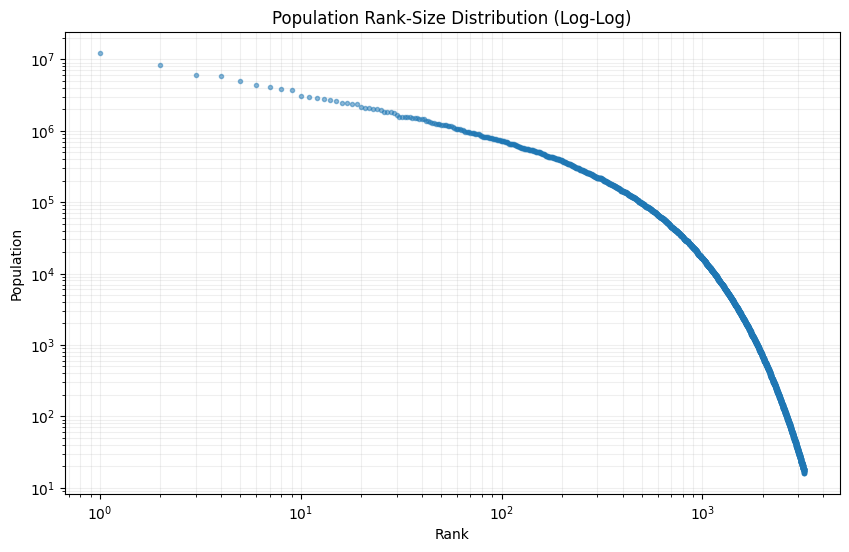

In [395]:
sorted_pop = np.sort(population)[::-1]
ranks = np.arange(1, len(sorted_pop) + 1)

plt.figure(figsize=(10, 6))
plt.loglog(ranks, sorted_pop, marker='.', linestyle='none', alpha=0.5)
plt.title("Population Rank-Size Distribution (Log-Log)")
plt.xlabel("Rank")
plt.ylabel("Population")
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

In [332]:
number_nodes= 3220
total_population=312969665


gamma = 0.55
decay_rate = 0.0028
rank = np.arange(1, number_nodes + 1)
zipf_term = 1 / ( rank ** gamma)
exponential_term = np.exp(-decay_rate * rank)
noise = np.random.lognormal(0, 0.05, number_nodes)



population_distribution = zipf_term * exponential_term * noise

population = ((population_distribution / population_distribution.sum()) * total_population).astype(int)
#population = np.maximum(population, 50)
population[0] += total_population - population.sum()

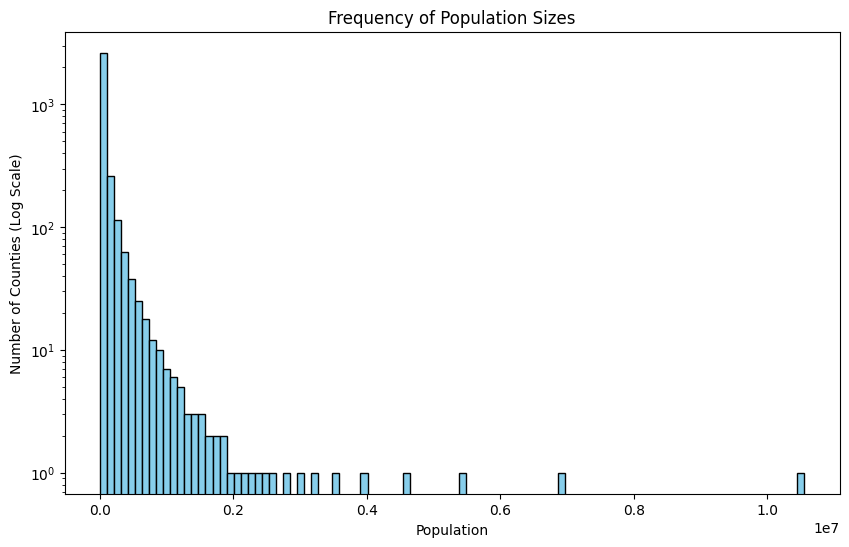

In [380]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(population, bins=100, color='skyblue', edgecolor='black', log=True)
plt.title("Frequency of Population Sizes")
plt.xlabel("Population")
plt.ylabel("Number of Counties (Log Scale)")
plt.show()

In [209]:
population.max()

10554477

In [63]:
def generate_and_save_dataset(num_graphs=10):
    all_graphs = {}
    all_features =  {}
    all_thresholds = []

    output_dir = 'datasets/version1'
    os.makedirs(output_dir, exist_ok=True)
    print(f"Saving to: {os.path.abspath(output_dir)}")

    for i in range(num_graphs):

        total_population = np.random.randint(1000000, 15000000)  # populatuon  large cities
        number_nodes= np.random.randint(350, 1000) #number of zip, codes
        total_area = np.random.randint(1500, 6000) #between 4000 and 15000 sq km in miles
        recovery_rate= 1


        graph, population, position = generate_graph(total_population, number_nodes,total_area, alpha=0)

        graph_coo = graph.tocoo()

        all_graphs[f'row_{i}'] = graph_coo.row
        all_graphs[f'col_{i}'] = graph_coo.col
        all_graphs[f'data_{i}'] = graph_coo.data

    # Store features as (N, 3) arrays
        all_features[f'feat_{i}'] = np.column_stack((population, position))

        threshold = calculate_threshold(graph, population, total_area, recovery_rate)
        all_thresholds.append(threshold)

        # sp.save_npz(f'{output_dir}/graph_{i}.npz', graph)
        #
        # node_data = np.column_stack((population, position))
        # np.save(f'{output_dir}/features_{i}.npy', node_data)
        #

        # np.save(f'{output_dir}/threshold_{i}.npy', threshold)

        if i % 10 == 0:
            print(f"Generated {i} graphs...")

    save_path = os.path.join(output_dir, 'mobility_metropolitan3.npz')
    np.savez_compressed(save_path, **all_graphs, **all_features, thresholds=np.array(all_thresholds))

In [64]:
generate_and_save_dataset(20)

Saving to: /Users/emmapinckers/PycharmProjects/thesis/data generation/datasets/version1
Generated 0 graphs...
Generated 10 graphs...
